In [ ]:
# Imports
from data_preprocessing import standardize_dates, add_days_to_floraison, NIRS_INDEXES, NIRS_INDEXES_INT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from utils import varimax
from scipy.signal import savgol_filter

In [ ]:
# Load and preprocess the data
data = pd.read_csv("./Data/CIRAD_Sorghum2023_SPIR_all_2 (4).csv", sep=";")
data = standardize_dates(data)
data = add_days_to_floraison(data)
data

,Genotype,Sample,ID,Date_Floraison,Date_SPIR,Traitement,Rep,Position,350,351,...,2492,2493,2494,2495,2496,2497,2498,2499,2500,Dates_Delta
0,Btx623,FreshLeaf,117,2023-05-19,2023-06-01,C,1,FlagLeaf,0.075652,0.070583,...,0.085991,0.085268,0.084832,0.084246,0.083982,0.083914,0.083658,0.083273,0.083111,13
1,Btx623,FreshLeaf,117,2023-05-19,2023-06-01,C,2,FlagLeaf,0.083377,0.082926,...,0.101342,0.101169,0.100833,0.100403,0.100057,0.099492,0.099523,0.099310,0.099126,13
2,Macia,FreshLeaf,203,2023-05-23,2023-06-01,SS2,1,FlagLeaf,0.078272,0.075389,...,0.078159,0.078018,0.077781,0.077200,0.077168,0.077273,0.077200,0.077064,0.076751,9
3,Macia,FreshLeaf,203,2023-05-23,2023-06-01,SS2,2,FlagLeaf,0.075764,0.074639,...,0.078284,0.078045,0.077868,0.077812,0.077722,0.077669,0.077620,0.077650,0.077399,9
4,Macia,FreshLeaf,215,2023-05-24,2023-06-01,C,1,FlagLeaf,0.061362,0.060504,...,0.068550,0.068382,0.068200,0.068012,0.067757,0.067621,0.067635,0.067188,0.067004,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2169,Btx623,GrainFlour,97,2023-05-17,2023-11-23,RS1,2,H,0.034959,0.030955,...,0.047863,0.047645,0.047588,0.047305,0.047117,0.047099,0.046816,0.046783,0.047026,190
2170,Btx623,GrainFlour,9,2023-05-17,2023-11-23,RS1,1,B,0.032963,0.032206,...,0.028890,0.028442,0.028247,0.028060,0.028358,0.028750,0.029092,0.029434,0.029362,190
2171,Btx623,GrainFlour,9,2023-05-17,2023-11-23,RS1,2,B,0.027549,0.022803,...,0.038462,0.038161,0.038029,0.037948,0.038023,0.038103,0.038269,0.038595,0.038484,190
2172,Btx623,GrainFlour,9,2023-05-17,2023-11-23,RS1,1,H,0.032928,0.029184,...,0.058592,0.058842,0.058885,0.059198,0.058971,0.058752,0.058847,0.058893,0.059020,190


In [ ]:
# ACP
n_pca = 3
X = data[NIRS_INDEXES].values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=n_pca)
X_pca = pca.fit_transform(X_scaled)


print("Explained variance ratio", pca.explained_variance_ratio_)
print("Total explained variance", np.sum(pca.explained_variance_ratio_))

X_reconstructed = pca.inverse_transform(X_pca)
residus = X_scaled - X_reconstructed

q_residuals = np.sum(residus**2, axis=1)
plt.figure(figsize=(10, 4))
plt.stem(q_residuals)
plt.title("Erreur de reconstruction par échantillon (Q-residuals)")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Somme des carrés des erreurs")
plt.show()

Explained variance ratio [0.78385687 0.11943057 0.07777356]
Total explained variance 0.9810609982289018


In [ ]:
# 1. Transposer pour avoir (longueurs_onde, composantes)
loadings = pca.components_.T 

# 2. Appliquer Varimax
loadings_rotated_T, R = varimax(loadings)

# 3. Transposer le résultat pour l'affichage (composantes, longueurs_onde)
loadings_varimax = loadings_rotated_T.T
loadings = pca.components_

# 4. TRÈS IMPORTANT : Tourner aussi tes scores pour que le nuage de points suive !
# Tes scores originaux sont (n_echantillons, n_composantes)
scores_varimax = np.dot(X_pca, R)

print("Rotation matrix R:\n", R)


Varimax: n_rows=2151, n_cols=3
Rotation matrix R:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


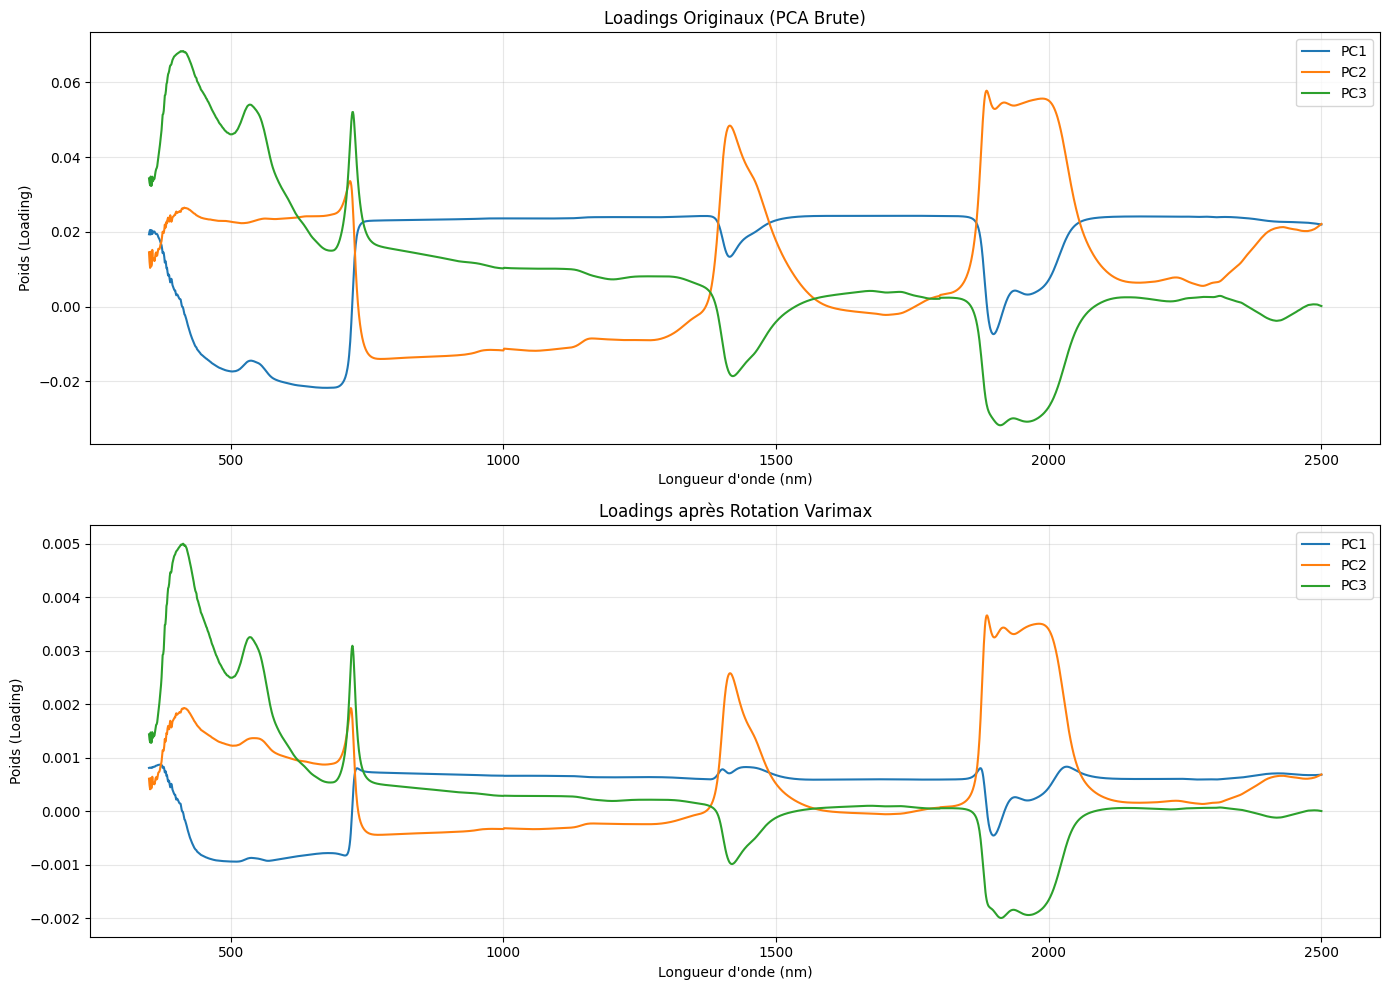

In [ ]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot original loadings
for i in range(n_pca):
    ax1.plot(NIRS_INDEXES_INT, loadings[i, :], label=f'PC{i+1}')
ax1.set_xlabel("Longueur d'onde (nm)")
ax1.set_ylabel('Poids (Loading)')
ax1.set_title('Loadings Originaux (PCA Brute)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot varimax rotated loadings
for i in range(n_pca):
    ax2.plot(NIRS_INDEXES_INT, loadings_varimax[i, :], label=f'PC{i+1}')
ax2.set_xlabel("Longueur d'onde (nm)")
ax2.set_ylabel('Poids (Loading)')
ax2.set_title('Loadings après Rotation Varimax')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Varimax: n_rows=2151, n_cols=3


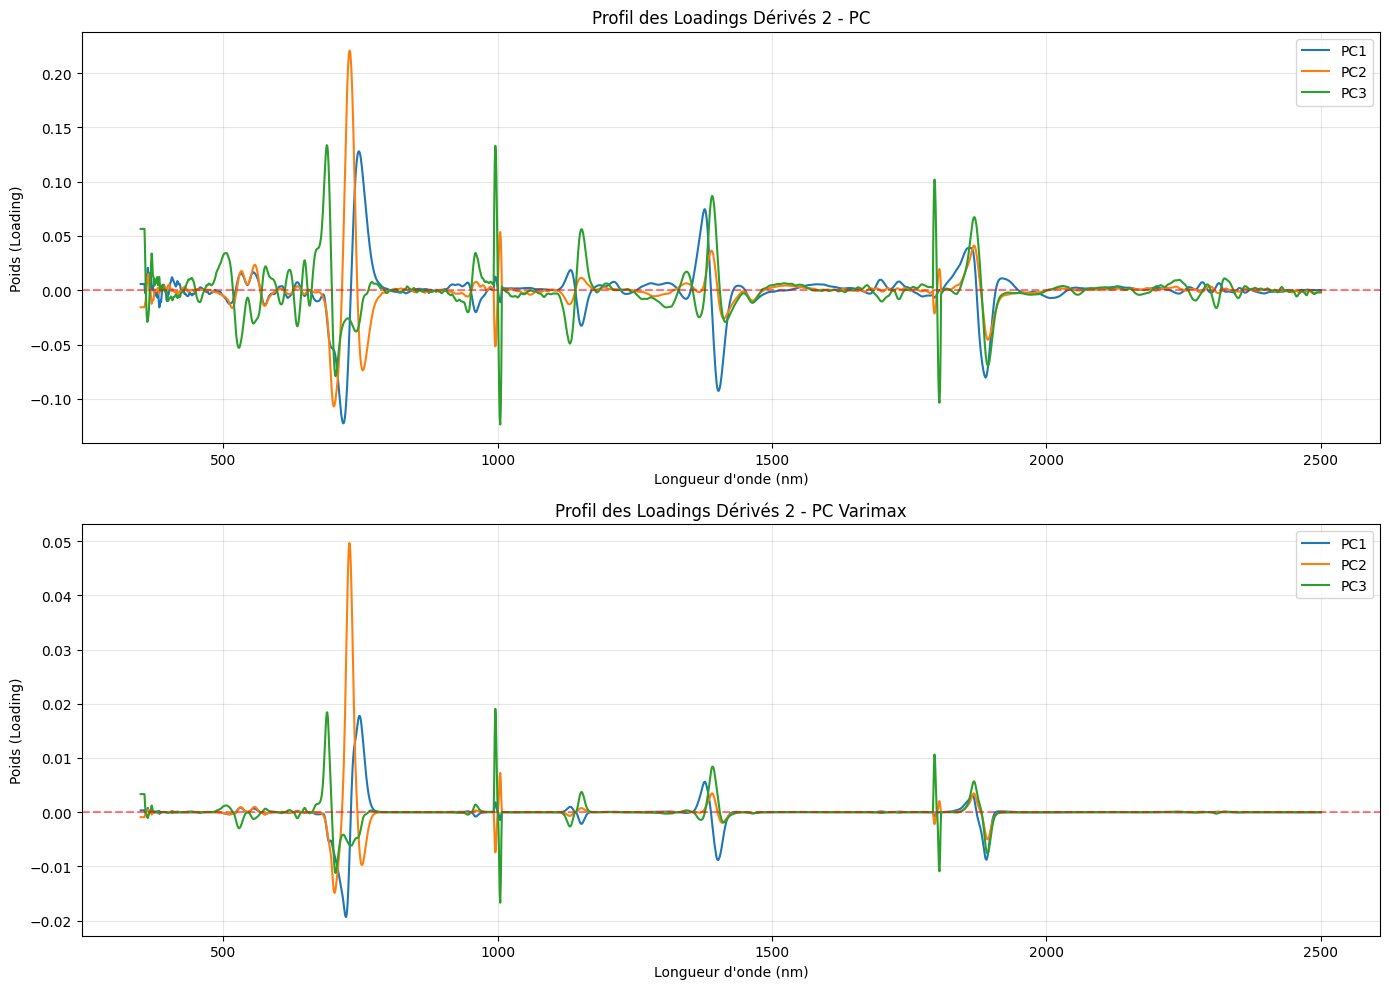

In [ ]:
# PCA et Varimax sur les dérivées secondes
X_derived = savgol_filter(X, window_length=15, polyorder=2, deriv=2)
pca_derived = PCA(n_components=n_pca)
X_derived_scaled = StandardScaler(with_std=False).fit_transform(X_derived)
X_derived_pca = pca_derived.fit_transform(X_derived_scaled)

loadings_derived = pca_derived.components_
loadings_derived_varimax, R = varimax(loadings_derived.T)
loadings_derived_varimax = loadings_derived_varimax.T

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Loadings dérivés (PCA brute)
for i in range(n_pca):
    ax1.plot(NIRS_INDEXES_INT, loadings_derived[i, :], label=f'PC{i+1}')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel("Longueur d'onde (nm)")
ax1.set_ylabel("Poids (Loading)")
ax1.set_title("Profil des Loadings Dérivés 2 - PC")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loadings dérivés après Varimax
for i in range(n_pca):
    ax2.plot(NIRS_INDEXES_INT, loadings_derived_varimax[i, :], label=f'PC{i+1}')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel("Longueur d'onde (nm)")
ax2.set_ylabel("Poids (Loading)")
ax2.set_title("Profil des Loadings Dérivés 2 - PC Varimax")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()